# Step 1: Import Libraries

In [1]:
"""
=============================================================
Task 02 - Customer Segmentation using K-Means Clustering
=============================================================
Dataset  : Mall_Customers.csv
Features : Annual Income (k$) & Spending Score (1-100)
Goal     : Group retail store customers based on purchase history
=============================================================
"""

# ─────────────────────────────────────────────
# STEP 1: Import Required Libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")


# Step 2: Load Dataset

In [2]:
# ─────────────────────────────────────────────
# STEP 2: Load & Explore the Dataset
# ─────────────────────────────────────────────
df = pd.read_csv("Mall_Customers.csv")
print(df)

print(f"Shape     : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns   : {list(df.columns)}")


     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]
Shape     : 200 rows × 5 columns
Columns   : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', '

In [3]:
print(f"\n  First 5 rows:")
print(df.head().to_string(index=False))


  First 5 rows:
 CustomerID Gender  Age  Annual Income (k$)  Spending Score (1-100)
          1   Male   19                  15                      39
          2   Male   21                  15                      81
          3 Female   20                  16                       6
          4 Female   23                  16                      77
          5 Female   31                  17                      40


In [4]:
print(f"\n  Dataset Info:")
print(f"  {'Column':<30} {'Non-Null':<12} {'Dtype'}")
print(f"  {'-'*50}")
for col in df.columns:
    print(f"  {col:<30} {df[col].notnull().sum():<12} {df[col].dtype}")


  Dataset Info:
  Column                         Non-Null     Dtype
  --------------------------------------------------
  CustomerID                     200          int64
  Gender                         200          str
  Age                            200          int64
  Annual Income (k$)             200          int64
  Spending Score (1-100)         200          int64


# Step 3: Exploratory Data Analysis (EDA)


In [5]:
print(f"\n  Null Values : {df.isnull().sum().sum()}  (No missing data!)")
print(f"\n  Basic Statistics:")
print(df.describe().round(2).to_string())


  Null Values : 0  (No missing data!)

  Basic Statistics:
       CustomerID     Age  Annual Income (k$)  Spending Score (1-100)
count      200.00  200.00              200.00                  200.00
mean       100.50   38.85               60.56                   50.20
std         57.88   13.97               26.26                   25.82
min          1.00   18.00               15.00                    1.00
25%         50.75   28.75               41.50                   34.75
50%        100.50   36.00               61.50                   50.00
75%        150.25   49.00               78.00                   73.00
max        200.00   70.00              137.00                   99.00


# Step 4: Boxplots — Outlier Detection


[STEP 2] Running Outlier Detection using Box Plots...


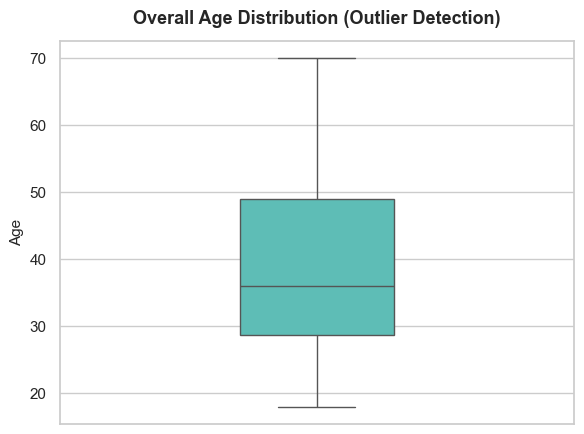

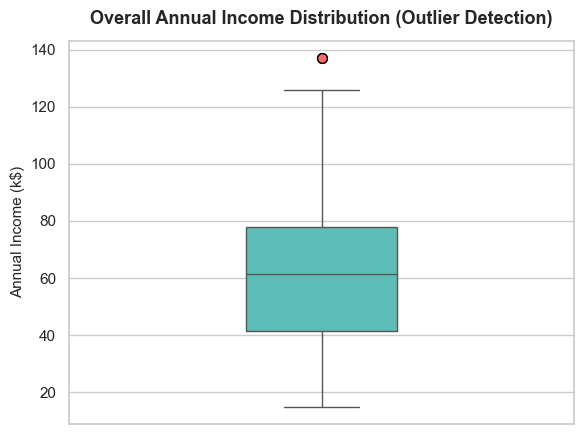

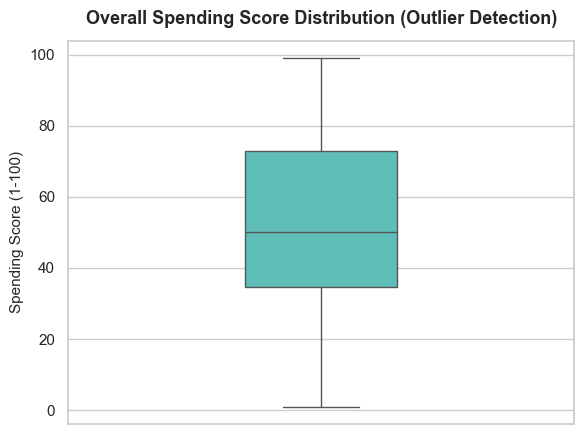

In [6]:

sns.set_theme(style="whitegrid")

# ─────────────────────────────────────────────
# STEP  4: Pre-Clustering Outlier Detection (Box Plots)
# ─────────────────────────────────────────────
print("\n[STEP 2] Running Outlier Detection using Box Plots...")

features_to_plot = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
titles = ["Overall Age Distribution (Outlier Detection)", 
          "Overall Annual Income Distribution (Outlier Detection)", 
          "Overall Spending Score Distribution (Outlier Detection)"]

# Plotting each feature as a separate individual graph before clustering
for i, col in enumerate(features_to_plot):
    plt.figure(figsize=(6, 4.5))
    
    # Removed x="Cluster" because clusters do not exist yet.
    # Using a professional teal color for the box and coral red for outliers.
    sns.boxplot(
        data=df, 
        y=col, 
        color="#4ECDC4", 
        width=0.3,
        flierprops=dict(marker='o', markerfacecolor='#FF6B6B', markersize=7, markeredgecolor='black')
    )
    
    plt.title(titles[i], fontsize=13, fontweight="bold", pad=12)
    plt.ylabel(col, fontsize=11)
    plt.tight_layout()
    plt.show()

# STEP 5: Feature Selection & Scaling

In [7]:
# ─────────────────────────────────────────────
# STEP 5: Feature Selection & Scaling
# ─────────────────────────────────────────────
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

print(f"Selected Features : Annual Income (k$)  &  Spending Score (1-100)")
print(f"Feature Matrix Shape : {X.shape}")


print("\nStandardizing Features (StandardScaler)...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaling Done  — Mean ≈ 0, Std ≈ 1 for each feature")

Selected Features : Annual Income (k$)  &  Spending Score (1-100)
Feature Matrix Shape : (200, 2)

Standardizing Features (StandardScaler)...
Scaling Done  — Mean ≈ 0, Std ≈ 1 for each feature


# STEP 6: Elbow Method — Find Optimal K



  K= 1  →  WCSS = 400.00
  K= 2  →  WCSS = 269.69
  K= 3  →  WCSS = 157.70
  K= 4  →  WCSS = 108.92
  K= 5  →  WCSS = 65.57
  K= 6  →  WCSS = 55.06
  K= 7  →  WCSS = 44.86
  K= 8  →  WCSS = 37.23
  K= 9  →  WCSS = 32.39
  K=10  →  WCSS = 29.98

 Optimal K identified at the 'elbow' of the curve.


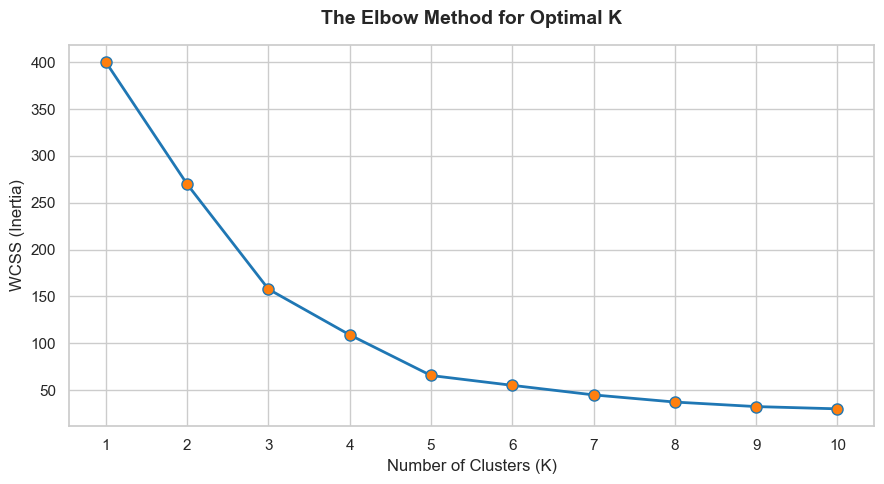

In [8]:
# ─────────────────────────────────────────────
# STEP 6: Elbow Method — Find Optimal K
# ─────────────────────────────────────────────

wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", max_iter=300,
                n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    print(f"  K={k:2d}  →  WCSS = {km.inertia_:.2f}")

print("\n Optimal K identified at the 'elbow' of the curve.")

# ─────────────────────────────────────────────
# GRAPH PLOTTING (Matplotlib & Seaborn)
# ─────────────────────────────────────────────
# Set Seaborn theme for better visuals
sns.set_theme(style="whitegrid")

# Create figure size
plt.figure(figsize=(9, 5))

# Plot the Elbow curve with lines and markers
plt.plot(K_range, wcss, marker='o', linestyle='-', color='#1f77b4', 
         linewidth=2, markersize=8, markerfacecolor='#ff7f0e')

# Add titles and labels
plt.title("The Elbow Method for Optimal K", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("WCSS (Inertia)", fontsize=12)

# Set exact X-axis ticks from 1 to 10
plt.xticks(K_range)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# STEP 7: Silhouette Score Validation

  K= 2  →  Silhouette Score = 0.3213
  K= 3  →  Silhouette Score = 0.4666
  K= 4  →  Silhouette Score = 0.4939
  K= 5  →  Silhouette Score = 0.5547
  K= 6  →  Silhouette Score = 0.5399
  K= 7  →  Silhouette Score = 0.5281
  K= 8  →  Silhouette Score = 0.4552
  K= 9  →  Silhouette Score = 0.4571
  K=10  →  Silhouette Score = 0.4432

 Best K suggested by Silhouette Score = 5


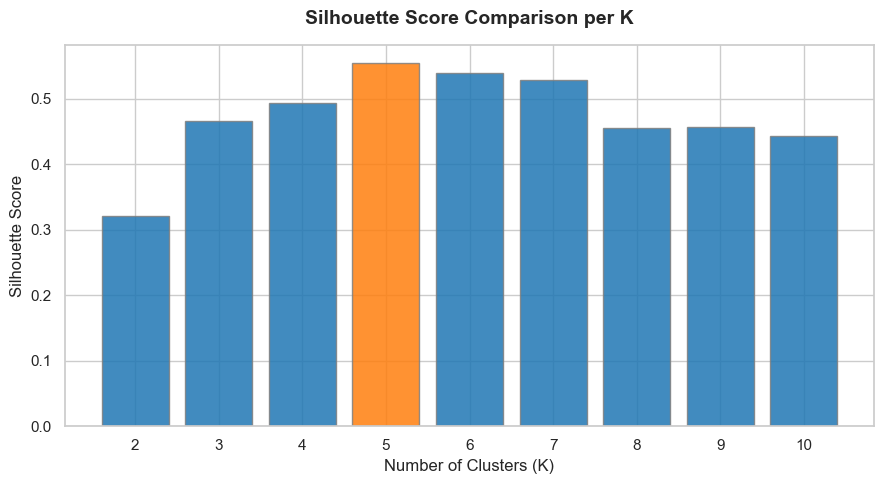

In [9]:
# ─────────────────────────────────────────────
# STEP 7: Silhouette Score Validation
# ─────────────────────────────────────────────
# Validating K using Silhouette Score

sil_scores = []
k_vals = list(range(2, 11))

for k in k_vals:
    km = KMeans(n_clusters=k, init="k-means++", max_iter=300,
                n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"  K={k:2d}  →  Silhouette Score = {score:.4f}")

best_k = np.argmax(sil_scores) + 2
print(f"\n Best K suggested by Silhouette Score = {best_k}")



#Plotting Silhouette Scores

plt.figure(figsize=(9, 5))

bar_colors = ["#1f77b4" if k != best_k else "#ff7f0e" for k in k_vals]
plt.bar(k_vals, sil_scores, color=bar_colors, edgecolor="#7f7f7f", alpha=0.85)

plt.title("Silhouette Score Comparison per K", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(k_vals)
plt.tight_layout()
plt.show()


# STEP 8: Train Final K-Means Model (K=5)


Training Final K-Means Model with K = 5...


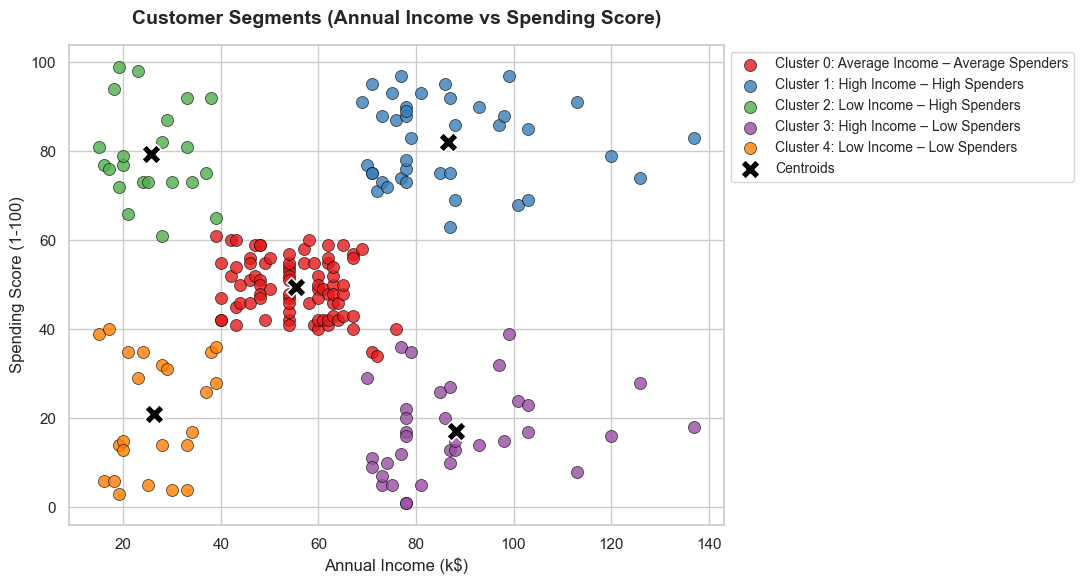

In [10]:
sns.set_theme(style="whitegrid")

# ─────────────────────────────────────────────
# STEP 8: Train Final K-Means Model (K=5)
# ─────────────────────────────────────────────
K = 5  # Optimal K selected from Elbow + Silhouette analysis
print(f"\nTraining Final K-Means Model with K = {K}...")

kmeans = KMeans(n_clusters=K, init="k-means++", max_iter=300,
                n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Dynamic labels logic with 'Average' cluster handling
overall_income_avg = df["Annual Income (k$)"].mean()
overall_spend_avg  = df["Spending Score (1-100)"].mean()

income_avg = df.groupby("Cluster")["Annual Income (k$)"].mean()
spend_avg  = df.groupby("Cluster")["Spending Score (1-100)"].mean()

def get_cluster_label(c):
    # 15% ka margin rukh rahe hain taake center wale data ko 'Average' label kiya ja sake
    income_margin = overall_income_avg * 0.15
    spend_margin = overall_spend_avg * 0.15
    
    # Income Check
    if abs(income_avg[c] - overall_income_avg) <= income_margin:
        inc = "Average Income"
    else:
        inc = "High Income" if income_avg[c] > overall_income_avg else "Low Income"
        
    # Spending Check
    if abs(spend_avg[c] - overall_spend_avg) <= spend_margin:
        spnd = "Average Spenders"
    else:
        spnd = "High Spenders" if spend_avg[c] > overall_spend_avg else "Low Spenders"
        
    # Agar dono average hain toh simple name
    if inc == "Average Income" and spnd == "Average Spenders":
        return "Average Income – Average Spenders"
        
    return f"{inc} – {spnd}"

# Apply the correct labels to the dataframe
df["Cluster_Label"] = df["Cluster"].map(get_cluster_label)


# ─────────────────────────────────────────────
# Plotting Customer Segments (Individual Graph)
# ─────────────────────────────────────────────
plt.figure(figsize=(11, 6))

# Custom color palette taake har cluster clean dikhe
cluster_colors = sns.color_palette("Set1", n_colors=K)

for c in range(K):
    mask = df["Cluster"] == c
    plt.scatter(df.loc[mask, "Annual Income (k$)"],
                df.loc[mask, "Spending Score (1-100)"],
                color=cluster_colors[c], s=75, alpha=0.8, 
                edgecolors="black", linewidths=0.5, 
                label=f"Cluster {c}: {get_cluster_label(c)}")

# Plotting Centroids (Inversing the scaling back to original scale)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            color="black", s=200, marker="X", edgecolors="white", 
            linewidths=1.2, zorder=5, label="Centroids")

plt.title("Customer Segments (Annual Income vs Spending Score)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)

# Legend ko graph se thoda bahar right side pe adjust kiya hai taake text overlaps na ho
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


# STEP 9: Cluster Profiling Summary Table



  Cluster    Count    Avg Age    Avg Income      Avg Spending    Auto Label
  ------------------------------------------------------------------------------------------
  0          81       42.72      55.3            49.52           Average Income – Average Spenders
  1          39       32.69      86.54           82.13           High Income – High Spenders
  2          22       25.27      25.73           79.36           Low Income – High Spenders
  3          35       41.11      88.2            17.11           High Income – Low Spenders
  4          23       45.22      26.3            20.91           Low Income – Low Spenders


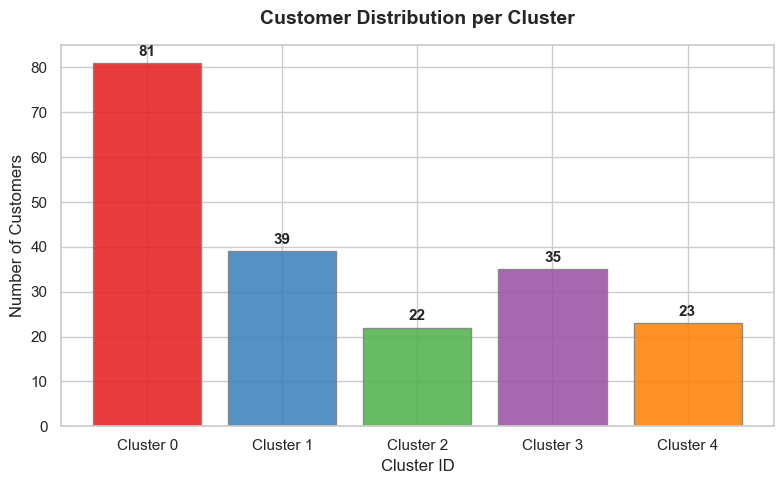

In [11]:
# ─────────────────────────────────────────────
# STEP 9: Cluster Profiling Summary Table
# ─────────────────────────────────────────────
#Profiling Each Customer Cluster

cluster_counts = df["Cluster"].value_counts().sort_index()
profile = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(2)
profile["Count"] = cluster_counts

print(f"\n  {'Cluster':<10} {'Count':<8} {'Avg Age':<10} {'Avg Income':<15} {'Avg Spending':<15} {'Auto Label'}")
print(f"  {'-'*90}")
for idx, row in profile.iterrows():
    print(f"  {idx:<10} {int(row['Count']):<8} {row['Age']:<10} {row['Annual Income (k$)']:<15} {row['Spending Score (1-100)']:<15} {get_cluster_label(idx)}")
    
    
# Customer Distribution Count

# Plotting Customer Counts per Cluster
plt.figure(figsize=(8, 5))

plt.bar([f"Cluster {c}" for c in range(K)], cluster_counts, color=cluster_colors, edgecolor="#7f7f7f", alpha=0.85)

plt.title("Customer Distribution per Cluster", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Cluster ID", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

for i, val in enumerate(cluster_counts):
    plt.text(i, val + 1, str(val), ha="center", va="bottom", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.show()

# Step 10: Boxplots — Outlier Detection


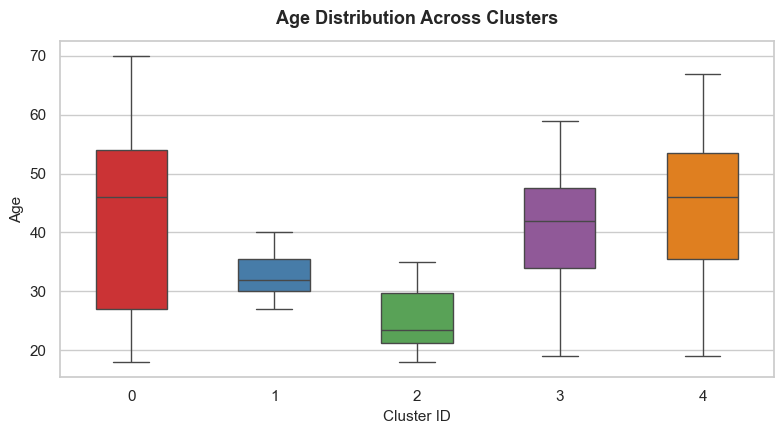

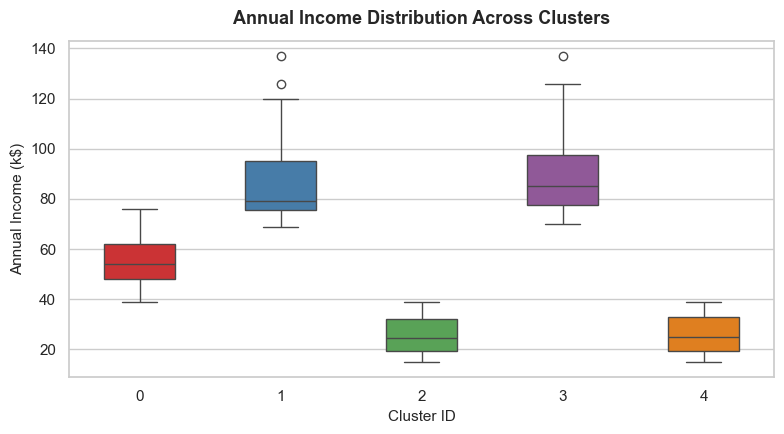

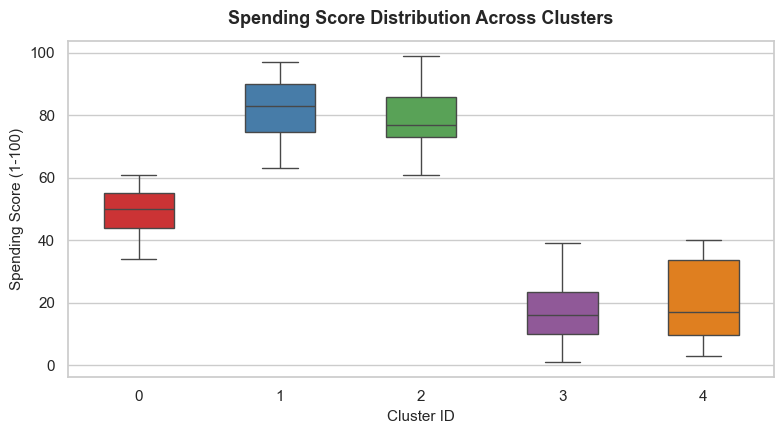

In [12]:
# ─────────────────────────────────────────────
# STEP 10: Advanced Feature Profiling (Boxplots)
# ─────────────────────────────────────────────
#Plotting Feature Distributions (Boxplots)...")
# Step 9: Boxplots — Outlier Detection

features_to_plot = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
titles = ["Age Distribution Across Clusters", 
          "Annual Income Distribution Across Clusters", 
          "Spending Score Distribution Across Clusters"]

# Plotting each feature as a separate individual graph
for i, col in enumerate(features_to_plot):
    plt.figure(figsize=(8, 4.5))
    sns.boxplot(data=df, x="Cluster", y=col, palette="Set1", width=0.5)
    plt.title(titles[i], fontsize=13, fontweight="bold", pad=12)
    plt.xlabel("Cluster ID", fontsize=11)
    plt.ylabel(col, fontsize=11)
    plt.tight_layout()
    plt.show()

# Main Clustering & Demographic Visualizations

# Cluster Size (Pie Chart)

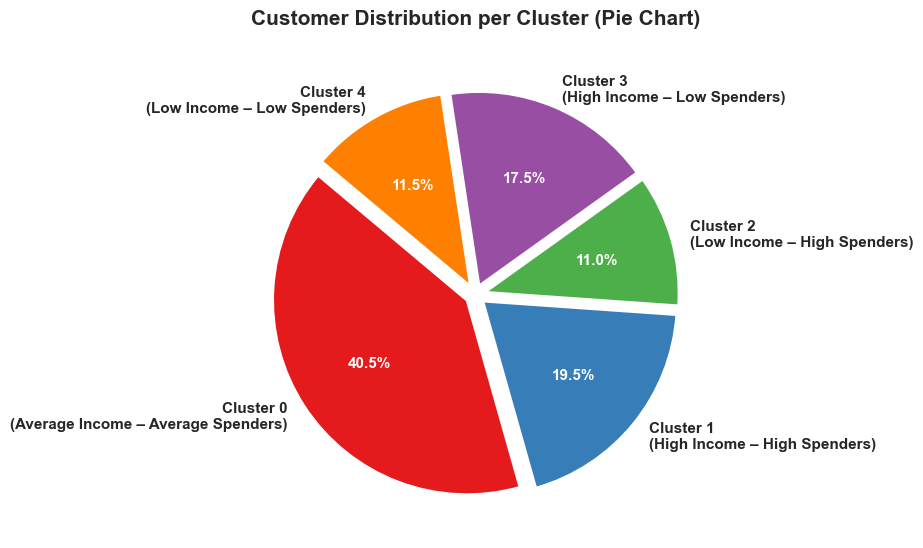

In [13]:

sns.set_theme(style="whitegrid")

# ────────────────────────────────═════════════════════════════
# GRAPH 5 — Cluster Size (Pie Chart)
# ────────────────────────────────═════════════════════════════

# Figure size setup (Pie chart ke liye square ratio 8x8 ya 9x9 best hota hai)
fig, ax = plt.subplots(figsize=(9, 9))

# Data counts extract karna (K=5 ke mutabiq)
counts = df["Cluster"].value_counts().sort_index()

# Slices ko thoda alag (separated) dikhane ke liye explode grid
explode = [0.05] * K  

# Professional color palette aapke clusters ke liye
cluster_colors = sns.color_palette("Set1", n_colors=K)

# Create dynamic labels including the smart name (e.g., "Cluster 0: Low Income – High Spenders")
pie_labels = [f"Cluster {c}\n({get_cluster_label(c)})" for c in counts.index]

# Plotting the Pie Chart
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=pie_labels,
    colors=cluster_colors,
    autopct="%1.1f%%",         # Percentage ko 1 decimal place tak dikhane ke liye
    startangle=140,            # Chart ko ek clean angle se start karne ke liye
    explode=explode,           # Slices ke darmiyan spacing
    wedgeprops=dict(edgecolor="white", linewidth=2) # Slices ke borders clear karne ke liye
)

# Outside text (Labels) ki styling aur formatting
for t in texts:
    t.set_fontsize(11)
    t.set_fontweight("semibold")
    t.set_color("#262626")    # Clean dark grey color for text readability

# Inside text (Percentage values) ki styling
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")     # Slices ke andar text ko bold white rakha hai taake saaf dikhe

# Title setup
plt.title("Customer Distribution per Cluster (Pie Chart)", fontsize=15, fontweight="bold", pad=20)

# Layout adjustment aur plot display
plt.tight_layout()
plt.show()





# Gender Distribution per Cluster (Stacked Bar)

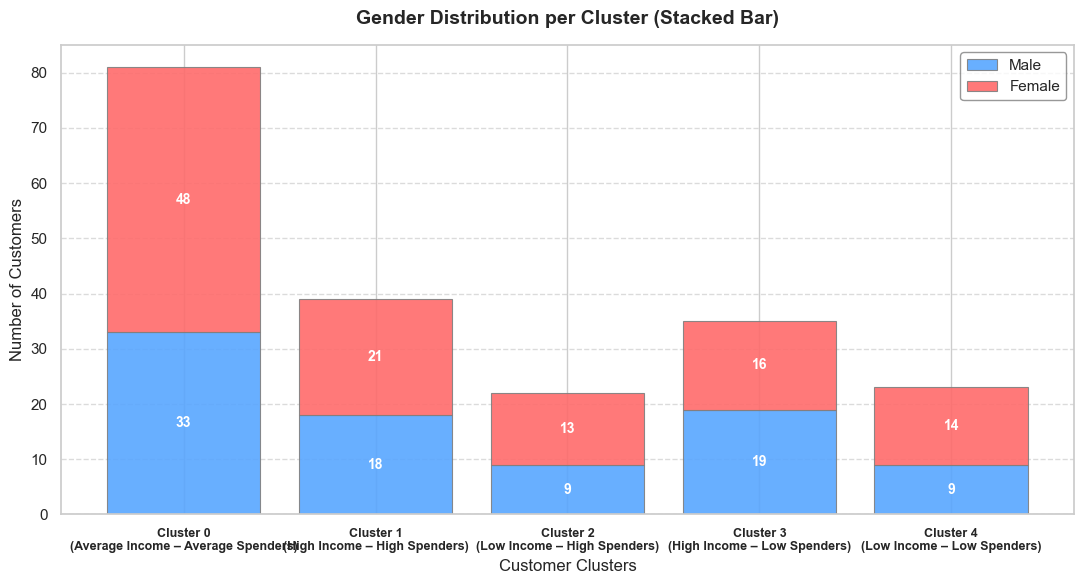

In [14]:


# Set professional corporate theme
sns.set_theme(style="whitegrid")

# ─────────────────────────────────────────────────────────────
# GRAPH 9 — Gender Distribution per Cluster (Stacked Bar)
# ─────────────────────────────────────────────────────────────

# Figure size and setup
fig, ax = plt.subplots(figsize=(11, 6))

# Custom palette matching your dynamic clusters
male_color = "#58A6FF"    # Cool Blue for Male
female_color = "#FF6B6B"  # Soft Coral for Female

# Group by Cluster and Gender to get counts
gender_cluster = df.groupby(["Cluster", "Gender"]).size().unstack(fill_value=0)
x = np.arange(K)

# Extract counts safely for each gender
male_vals   = gender_cluster.get("Male",   pd.Series([0]*K)).values
female_vals = gender_cluster.get("Female", pd.Series([0]*K)).values

# Plot Stacked Bars
bars_m = ax.bar(x, male_vals, color=male_color, label="Male",
                edgecolor="#7f7f7f", linewidth=0.8, alpha=0.9)
bars_f = ax.bar(x, female_vals, bottom=male_vals, color=female_color, label="Female",
                edgecolor="#7f7f7f", linewidth=0.8, alpha=0.9)

# Add value labels inside the Male bars segment
for bar, val in zip(bars_m, male_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val/2,
                str(val), ha="center", va="center",
                fontsize=10, fontweight="bold", color="white")

# Add value labels inside the Female bars segment
for bar, mval, fval in zip(bars_f, male_vals, female_vals):
    if fval > 0:
        ax.text(bar.get_x() + bar.get_width()/2, mval + fval/2,
                str(fval), ha="center", va="center",
                fontsize=10, fontweight="bold", color="white")

# Graph Titles and Labels Setup
plt.title("Gender Distribution per Cluster (Stacked Bar)", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Number of Customers", fontsize=12)
ax.set_xlabel("Customer Clusters", fontsize=12)

# Dynamic X-Axis Labels using the smart 'get_cluster_label' function from previous step
cluster_labels_with_names = [f"Cluster {c}\n({get_cluster_label(c)})" for c in range(K)]
ax.set_xticks(x)
ax.set_xticklabels(cluster_labels_with_names, fontsize=9, fontweight="semibold")

# Move legend outside or corner to prevent overlapping with bars
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#7f7f7f")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)

# Adjust layout and display graph instantly here
plt.tight_layout()
plt.show()

# Age Distribution per Cluster (Box Plot)

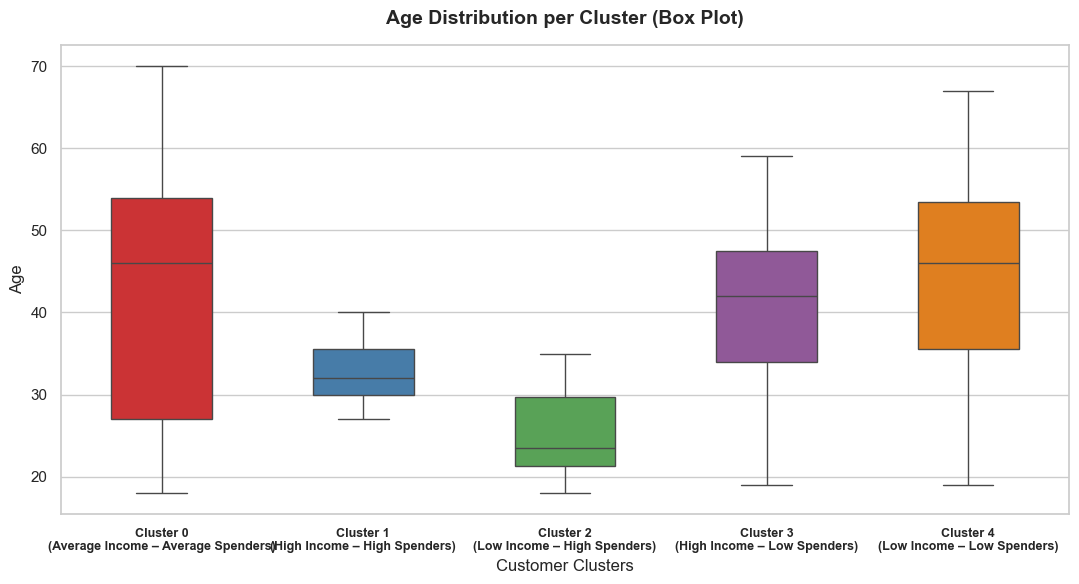

In [15]:

sns.set_theme(style="whitegrid")

# ────────────────────────────────═════════════════════════════
# GRAPH 6 — Age Distribution per Cluster (Box Plot)
# ────────────────────────────────═════════════════════════════

# Figure size setup
plt.figure(figsize=(11, 6))

# Professional color palette aapke clusters ke liye
cluster_colors = sns.color_palette("Set1", n_colors=K)

# Plotting Boxplot using Seaborn
# 'width=0.5' boxes ko clean aur properly spaced banata hai
ax = sns.boxplot(
    data=df, 
    x="Cluster", 
    y="Age", 
    palette=cluster_colors, 
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor='#7f7f7f', markersize=5, markeredgecolor='none') # Outliers styling
)

# Title and labels setup
plt.title("Age Distribution per Cluster (Box Plot)", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Age", fontsize=12)
plt.xlabel("Customer Clusters", fontsize=12)

# Dynamic X-Axis Labels using the smart 'get_cluster_label' function from previous steps
cluster_labels_with_names = [f"Cluster {c}\n({get_cluster_label(c)})" for c in range(K)]
ax.set_xticks(range(K))
ax.set_xticklabels(cluster_labels_with_names, fontsize=9, fontweight="semibold")

# Layout adjustment aur plot display instantly here
plt.tight_layout()
plt.show()

# Correlation Heatmap


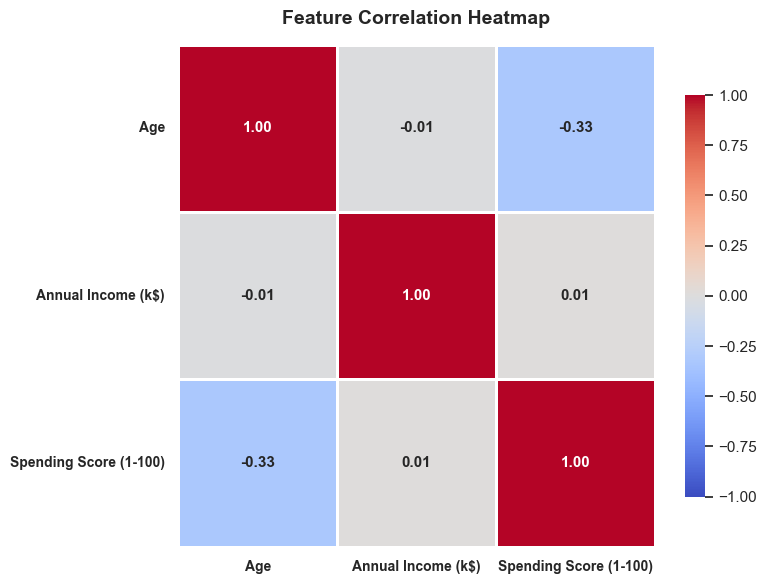

In [16]:

sns.set_theme(style="whitegrid")

# ────────────────────────────────═════════════════════════════
# GRAPH 11 — Correlation Heatmap
# ────────────────────────────────═════════════════════════════


# Figure size setup
plt.figure(figsize=(8, 6))

# Correlation sirf numeric feature columns ka nikalna chahiye (Cluster ID ko exclude kar ke)
numeric_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
corr = df[numeric_features].corr()

# Plotting the heatmap using Seaborn
# 'coolwarm' palette correlations ko dekhne ke liye sabse best aur professional mana jata hai
sns.heatmap(corr, 
            annot=True,              # Har box ke andar exact value dikhane ke liye
            fmt=".2f",               # Value ko 2 decimal places tak rukhne ke liye
            cmap="coolwarm",         # Professional blue-to-red gradient color scheme
            linewidths=0.8,          # Boxes ke darmiyan saaf line lagane ke liye
            linecolor="white",       # Border line ka color white rukhne ke liye
            annot_kws={"size": 11, "weight": "bold"}, # Text ko bold aur clear karne ke liye
            cbar_kws={"shrink": 0.8},# Colorbar ka size adjust karne ke liye
            vmin=-1, vmax=1)         # Correlation scale ko fixed -1 se +1 rukhne ke liye

# Title and labels setup
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold", pad=15)

# Ticks ko thoda saaf aur readable banaya hai
plt.xticks(fontsize=10, fontweight="semibold")
plt.yticks(fontsize=10, fontweight="semibold", rotation=0)

# Adjust layout and display graph instantly here
plt.tight_layout()
plt.show()

# Primary Visualizations (4-Panel Dashboard)

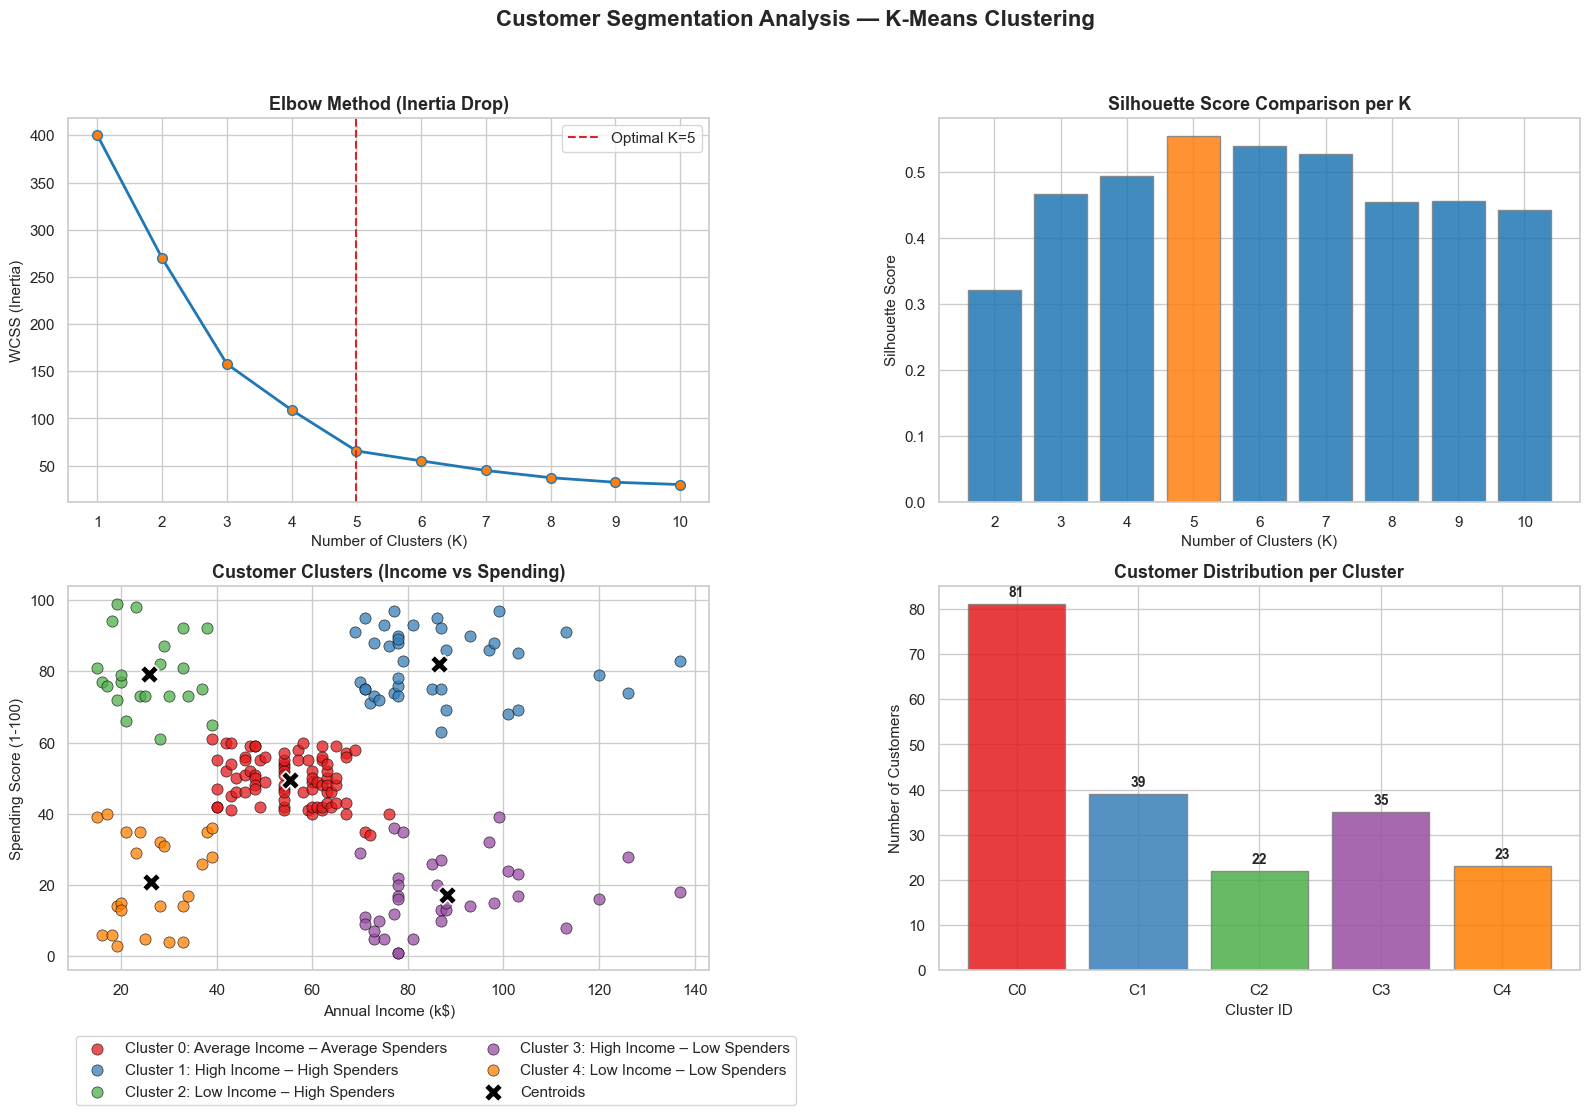

 Dashboard saved successfully as → kmeans_segmentation_dashboard.png


In [17]:
# ─────────────────────────────────────────────
# STEP : Primary Visualizations (4-Panel Dashboard)
# ─────────────────────────────────────────────

# Set clean, professional corporate theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10, "axes.labelsize": 11, "axes.titlesize": 13})

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Customer Segmentation Analysis — K-Means Clustering", fontsize=16, fontweight="bold", y=0.98)

# 1. Elbow Method Curve
axes[0, 0].plot(list(K_range), wcss, "o-", color="#1f77b4", linewidth=2, markersize=7, markerfacecolor="#ff7f0e")
axes[0, 0].axvline(x=K, color="#d62728", linestyle="--", linewidth=1.5, label=f"Optimal K={K}")
axes[0, 0].set_title("Elbow Method (Inertia Drop)", fontweight="bold")
axes[0, 0].set_xlabel("Number of Clusters (K)")
axes[0, 0].set_ylabel("WCSS (Inertia)")
axes[0, 0].set_xticks(list(K_range))
axes[0, 0].legend()

# 2. Silhouette Scores Comparison
bar_colors = ["#1f77b4" if k != best_k else "#ff7f0e" for k in k_vals]
axes[0, 1].bar(k_vals, sil_scores, color=bar_colors, edgecolor="#7f7f7f", alpha=0.85)
axes[0, 1].set_title("Silhouette Score Comparison per K", fontweight="bold")
axes[0, 1].set_xlabel("Number of Clusters (K)")
axes[0, 1].set_ylabel("Silhouette Score")
axes[0, 1].set_xticks(k_vals)

# 3. Customer Segments Scatter Plot
cluster_colors = sns.color_palette("Set1", n_colors=K)
for c in range(K):
    mask = df["Cluster"] == c
    axes[1, 0].scatter(df.loc[mask, "Annual Income (k$)"],
                        df.loc[mask, "Spending Score (1-100)"],
                        color=cluster_colors[c], s=65, alpha=0.75, 
                        edgecolors="black", linewidths=0.5, label=f"Cluster {c}: {get_cluster_label(c)}")

# Plotting Centroids
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
axes[1, 0].scatter(centroids_orig[:, 0], centroids_orig[:, 1],
                    color="black", s=180, marker="X", edgecolors="white", 
                    linewidths=1.2, zorder=5, label="Centroids")
axes[1, 0].set_title("Customer Clusters (Income vs Spending)", fontweight="bold")
axes[1, 0].set_xlabel("Annual Income (k$)")
axes[1, 0].set_ylabel("Spending Score (1-100)")
axes[1, 0].legend(loc="upper left", bbox_to_anchor=(0, -0.15), ncol=2, frameon=True)

# 4. Customer Density / Count per Cluster
axes[1, 1].bar([f"C{c}" for c in range(K)], cluster_counts, color=cluster_colors, edgecolor="#7f7f7f", alpha=0.85)
axes[1, 1].set_title("Customer Distribution per Cluster", fontweight="bold")
axes[1, 1].set_xlabel("Cluster ID")
axes[1, 1].set_ylabel("Number of Customers")
for i, val in enumerate(cluster_counts):
    axes[1, 1].text(i, val + 1, str(val), ha="center", va="bottom", fontweight="bold")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("kmeans_segmentation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Dashboard saved successfully as → kmeans_segmentation_dashboard.png")



In [18]:
# ─────────────────────────────────────────────
# STEP 10: Save Results to CSV
# ─────────────────────────────────────────────
print("\n Saving Clustered Data...")

output = df.copy()
output["Cluster_Label"] = output["Cluster"].map(lambda c: label_cluster(c))
output.to_csv("Mall_Customers_Clustered.csv", index=False)
print("Results saved as  →  Mall_Customers_Clustered.csv")


 Saving Clustered Data...


NameError: name 'label_cluster' is not defined

In [ ]:


# Dictionary to map cluster IDs to your custom business labels
cluster_labels = {
    0: "Average Income – Average Spenders",
    1: "High Income – High Spenders",
    2: "Low Income – High Spenders",
    3: "High Income – Low Spenders",
    4: "Low Income – Low Spenders"
}

def label_cluster(c):
    return cluster_labels.get(c, "Unknown Cluster")

# Value counts nikalna har cluster ki
cluster_counts = df['Cluster'].value_counts().to_dict()

# ─────────────────────────────────────────────
# STEP 11: Final Summary
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("   FINAL SUMMARY")
print("=" * 60)
print(f"  Algorithm       : K-Means Clustering (k-means++ init)")
print(f"  Optimal K       : {K}")
print(f"  Total Customers : {len(df)}")
print(f"  WCSS (Inertia)  : {kmeans.inertia_:.4f}")
print(f"  Silhouette Score: {silhouette_score(X_scaled, df['Cluster']):.4f}")
print(f"\n  Cluster Breakdown:")

# Exact output sequence (0 se lekar K-1 tak) maintain karne ke liye loop
for c in range(K):
    cnt = cluster_counts.get(c, 0)
    pct = (cnt / len(df)) * 100
    print(f"    Cluster {c} ({cnt} customers, {pct:.1f}%) → {label_cluster(c)}")

print("\n  Output Files:")
print("kmeans_segmentation_dashboard.png         (4-panel visualization)")
print("Mall_Customers_Clustered.csv (data with cluster labels)") 


   FINAL SUMMARY
  Algorithm       : K-Means Clustering (k-means++ init)
  Optimal K       : 5
  Total Customers : 200
  WCSS (Inertia)  : 65.5684
  Silhouette Score: 0.5547

  Cluster Breakdown:
    Cluster 0 (81 customers, 40.5%) → Average Income – Average Spenders
    Cluster 1 (39 customers, 19.5%) → High Income – High Spenders
    Cluster 2 (22 customers, 11.0%) → Low Income – High Spenders
    Cluster 3 (35 customers, 17.5%) → High Income – Low Spenders
    Cluster 4 (23 customers, 11.5%) → Low Income – Low Spenders

  Output Files:
kmeans_segmentation_dashboard.png         (4-panel visualization)
Mall_Customers_Clustered.csv (data with cluster labels)
